In [ ]:
# Install Stationarity Test (ADF and KPSS)
!pip install statsmodels

In [ ]:
# Upgrade Scikitlearn
!pip install -U scikit-learn

In [ ]:
# Prepare the library dan load the dataset
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('sample_data/data_emas.csv')

In [ ]:
# Clasify The Variables
dates = df['Periode']

# Variabel terikat
Y = df['gold_price']

# Variabel bebas
X = df[['inflation', 'interest', 'USD_rate']]

In [ ]:
df.head()

,Periode,gold_price,inflation,interest,USD_rate
0,Januari 2013,462000,0.0457,5.75,9666
1,Februari 2013,467500,0.0531,5.75,9680
2,Maret 2013,460000,0.0590,5.75,9705
3,13-Apr,437500,0.0557,5.75,9723
4,Mei 2013,420000,0.0547,5.75,9786


In [ ]:
# ADF Test
# Null hypothesis (H₀): Variable is non-stationary
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['gold_price'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Stationary")
else:
    print("Non-stationary")

ADF Statistic: 5.8178527072365
p-value: 1.0
Non-stationary


In [ ]:
# KPSS Test
# Null hypothesis (H₀): Variable is stationary
from statsmodels.tsa.stattools import kpss

result = kpss(df['gold_price'])

print("KPSS Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Non-stationary")
else:
    print("Stationary")

KPSS Statistic: 1.5110551314543386
p-value: 0.01
Non-stationary


/tmp/ipykernel_15340/2276245594.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(df['gold_price'])


In [ ]:
# Data dimension
print('harga_emas', df)

harga_emas            Periode  gold_price  inflation  interest  USD_rate
0     Januari 2013      462000     0.0457      5.75      9666
1    Februari 2013      467500     0.0531      5.75      9680
2       Maret 2013      460000     0.0590      5.75      9705
3           13-Apr      437500     0.0557      5.75      9723
4         Mei 2013      420000     0.0547      5.75      9786
..             ...         ...        ...       ...       ...
150      Juli 2025     1599809     0.0237      5.25     16286
151   Agustus 2025     1587626     0.0231      5.00     16309
152         25-Sep     1635791     0.0265      4.75     16523
153   Oktober 2025     1819979     0.0286      4.75     16604
154         25-Nov     1981275     0.0272      4.75     16705

[155 rows x 5 columns]


In [ ]:
# Cek missing value dengan fungsi isnull()
df.isnull().sum()

,0
Periode,0
gold_price,0
inflation,0
interest,0
USD_rate,0


In [ ]:
# Check apakah ada data numeric yang masih object, belum float64 ataupun int64
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Periode     155 non-null    object 
 1   gold_price  155 non-null    int64  
 2   inflation   155 non-null    float64
 3   interest    155 non-null    float64
 4   USD_rate    155 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 6.2+ KB


In [ ]:
# Rubah data numeric object menjadi float64
df['gold_price'] = pd.to_numeric(df['gold_price'], errors='coerce').astype('float64')
df['inflation'] = pd.to_numeric(df['inflation'], errors='coerce').astype('float64')
df['USD_rate'] = pd.to_numeric(df['USD_rate'], errors='coerce').astype('float64')

In [ ]:
# Check ulang semua data numeric sudah berubah menjadi float64 belum
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Periode     155 non-null    object 
 1   gold_price  155 non-null    float64
 2   inflation   155 non-null    float64
 3   interest    155 non-null    float64
 4   USD_rate    155 non-null    float64
dtypes: float64(4), object(1)
memory usage: 6.2+ KB


In [ ]:
print('harga_emas', df)

harga_emas            Periode  gold_price  inflation  interest  USD_rate
0     Januari 2013    462000.0     0.0457      5.75    9666.0
1    Februari 2013    467500.0     0.0531      5.75    9680.0
2       Maret 2013    460000.0     0.0590      5.75    9705.0
3           13-Apr    437500.0     0.0557      5.75    9723.0
4         Mei 2013    420000.0     0.0547      5.75    9786.0
..             ...         ...        ...       ...       ...
150      Juli 2025   1599809.0     0.0237      5.25   16286.0
151   Agustus 2025   1587626.0     0.0231      5.00   16309.0
152         25-Sep   1635791.0     0.0265      4.75   16523.0
153   Oktober 2025   1819979.0     0.0286      4.75   16604.0
154         25-Nov   1981275.0     0.0272      4.75   16705.0

[155 rows x 5 columns]


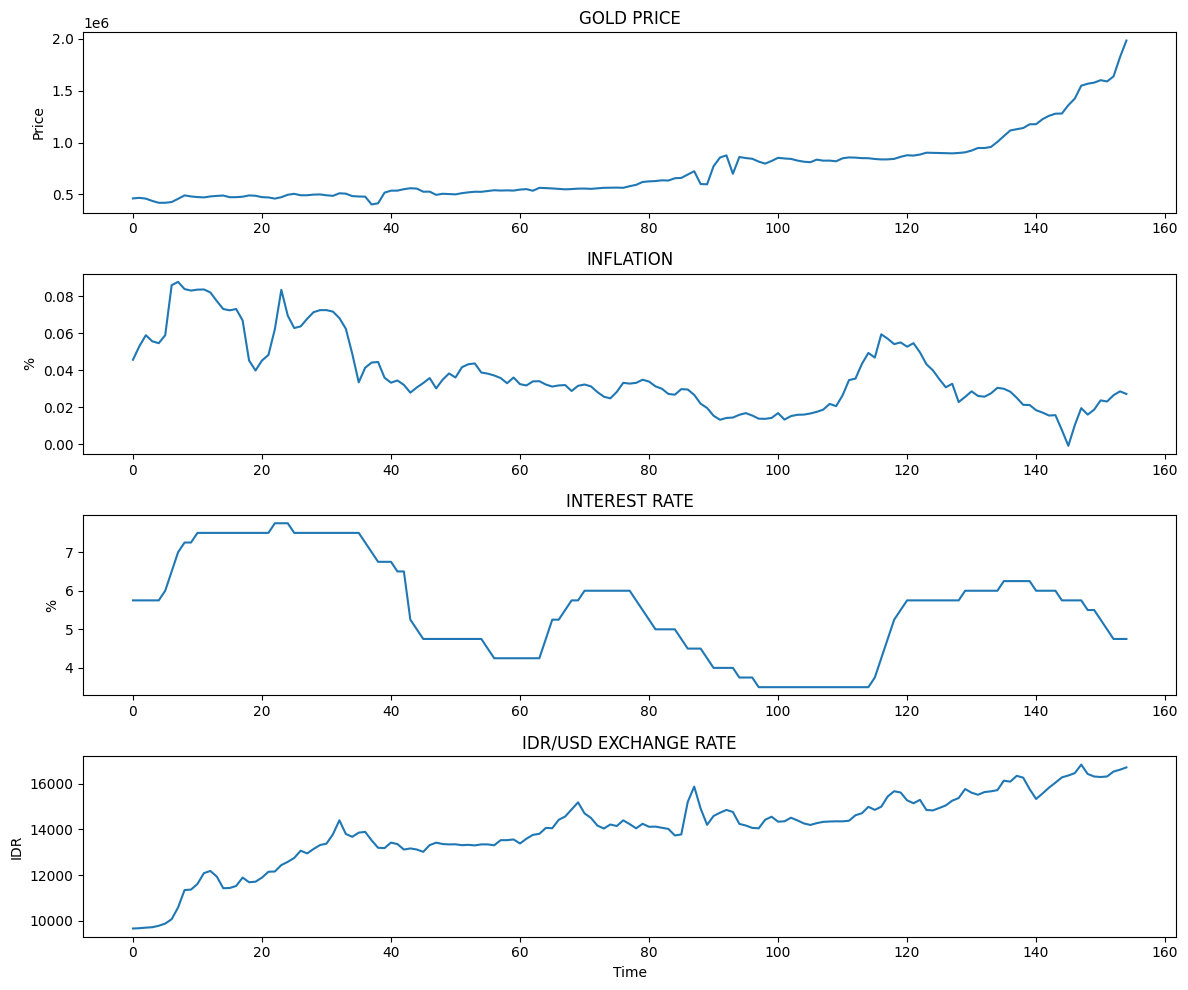

In [ ]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 10))

# Harga emas
plt.subplot(4, 1, 1)
plt.plot(df.index, Y)
plt.title('GOLD PRICE')
plt.ylabel('Price')

# Inflasi
plt.subplot(4, 1, 2)
plt.plot(df.index, X['inflation'])
plt.title('INFLATION')
plt.ylabel('%')

# Suku bunga
plt.subplot(4, 1, 3)
plt.plot(df.index, X['interest'])
plt.title('INTEREST RATE')
plt.ylabel('%')

# Nilai tukar
plt.subplot(4, 1, 4)
plt.plot(df.index, X['USD_rate'])
plt.title('IDR/USD EXCHANGE RATE')
plt.ylabel('IDR')

plt.xlabel('Time')
plt.tight_layout()
plt.show()

In [ ]:
# Descriptive Statistics
df.describe()

,gold_price,inflation,interest,USD_rate
count,1.550000e+02,155.000000,155.000000,155.000000
mean,7.346612e+05,0.037776,5.527419,13991.361290
std,3.132095e+05,0.019617,1.302024,1586.468224
min,4.040000e+05,-0.000900,3.500000,9666.000000
25%,5.051875e+05,0.025350,4.500000,13312.000000
50%,5.795920e+05,0.032800,5.750000,14166.000000
75%,8.560050e+05,0.047600,6.250000,14986.000000
max,1.981275e+06,0.087900,7.750000,16827.000000


In [ ]:
print('harga_emas', df)

harga_emas            Periode  gold_price  inflation  interest  USD_rate
0     Januari 2013    462000.0     0.0457      5.75    9666.0
1    Februari 2013    467500.0     0.0531      5.75    9680.0
2       Maret 2013    460000.0     0.0590      5.75    9705.0
3           13-Apr    437500.0     0.0557      5.75    9723.0
4         Mei 2013    420000.0     0.0547      5.75    9786.0
..             ...         ...        ...       ...       ...
150      Juli 2025   1599809.0     0.0237      5.25   16286.0
151   Agustus 2025   1587626.0     0.0231      5.00   16309.0
152         25-Sep   1635791.0     0.0265      4.75   16523.0
153   Oktober 2025   1819979.0     0.0286      4.75   16604.0
154         25-Nov   1981275.0     0.0272      4.75   16705.0

[155 rows x 5 columns]


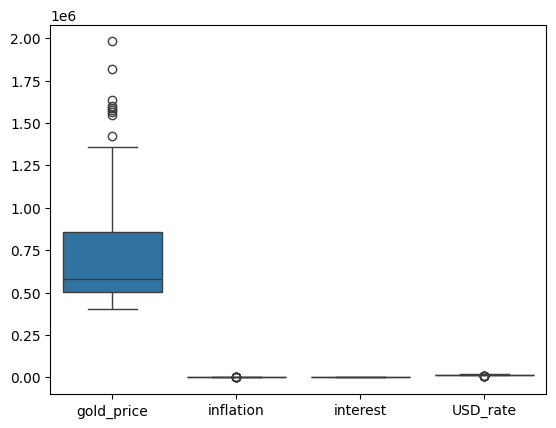

In [ ]:
# Outliers detection all variables in one chart
sns.boxplot(data=df)
plt.show()


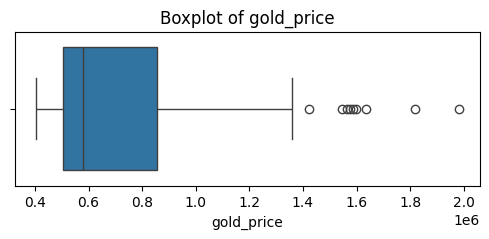

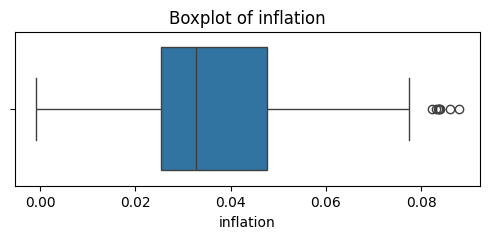

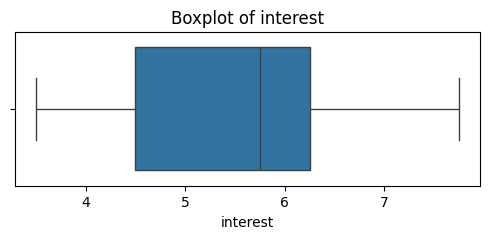

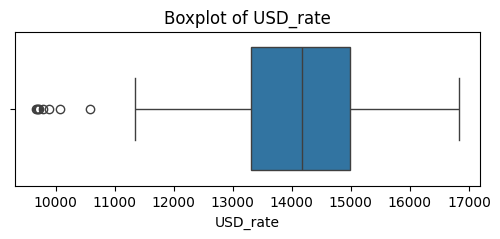

In [ ]:
# Outliers detection for each variable
import matplotlib.pyplot as plt
import seaborn as sns
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

<Axes: >

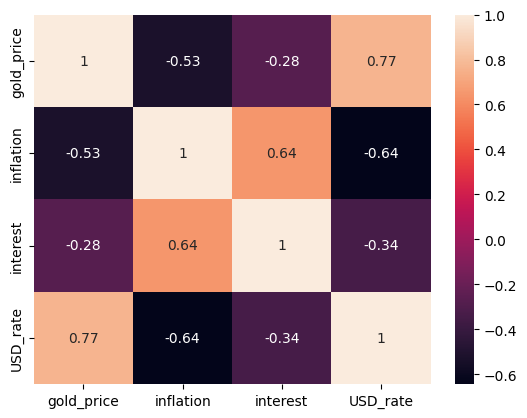

In [ ]:
# Correlation Analysis
corr = df.iloc[:,1:].corr()

sns.heatmap(corr, annot=True)

In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Build Random Forest Model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [ ]:
# Prediction
y_pred = rf.predict(X_test)

In [ ]:
print(rf.fit)

<bound method BaseForest.fit of RandomForestRegressor(max_depth=10, n_estimators=500, random_state=42)>


In [ ]:
print(y_pred)

[ 601961.82868571 1153622.128       499738.57058333  496808.89659307
  898880.94        538107.65061938  864294.71491905 1537863.256
 1750754.704       807295.72053333  543006.03829817 1310148.53
  573408.53612857  569665.96770238  485791.9187518   506344.10966111
  496185.78550974  835905.10807583  852152.81533333 1368394.966
  474450.82831349  472823.19464286  479670.41134921  478700.04702381
  869868.956       952237.07266667  823109.18875     536972.89174795
  786882.65933333  589342.28506667  852446.56733333]


In [ ]:
# Evaluate Accuracy
# R2 (Coeficient of Determination)
# MAPE (Percentage Accuracy)
# RMSE
# MAE (Average Absolute Error)

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.metrics import mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)

mape = 100 * np.mean(np.abs((y_test - y_pred) / y_test))

print("R² =", r2)
print("RMSE =", rmse)
print("MAE =", mae)
print("MAPE =", mape)

R² = 0.903895853589054
RMSE = 101630.703961626
MAE = 60495.94083914811
MAPE = 8.311890278700007


In [ ]:
# Variable Importance
import pandas as pd

importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(importance)

    Variable  Importance
2   USD_rate    0.859282
1   interest    0.097604
0  inflation    0.043114


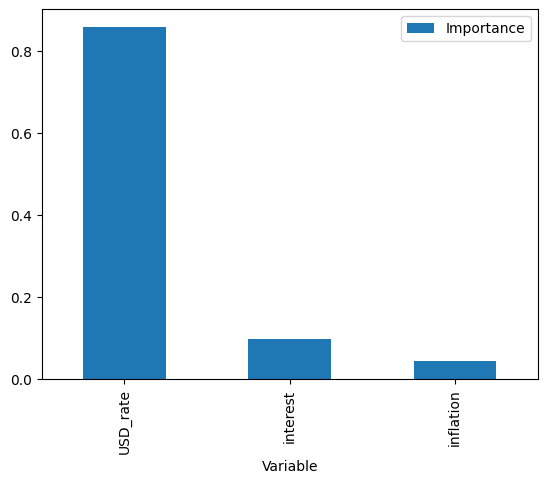

In [ ]:
#Visualize Importance
import matplotlib.pyplot as plt

importance.plot(
    x='Variable',
    y='Importance',
    kind='bar'
)

plt.show()

In [ ]:
# SHAP Analysis (Strongly Recommended)
!pip install shap

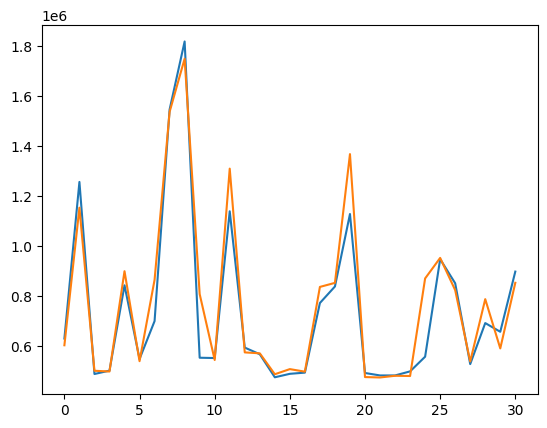

In [ ]:
# Prediction vs Actual Plot
import shap
plt.plot(y_test.values)
plt.plot(y_pred)

(array([ 1.,  2.,  0.,  2.,  0.,  2.,  1., 17.,  3.,  3.]),
 array([-313736.956 , -272042.7732, -230348.5904, -188654.4076,
        -146960.2248, -105266.042 ,  -63571.8592,  -21877.6764,
          19816.5064,   61510.6892,  103204.872 ]),
 <BarContainer object of 10 artists>)

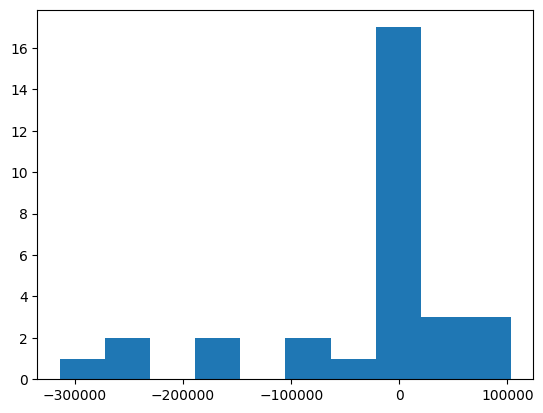

In [ ]:
# Residual Analysis
residuals = y_test - y_pred
plt.hist(residuals)

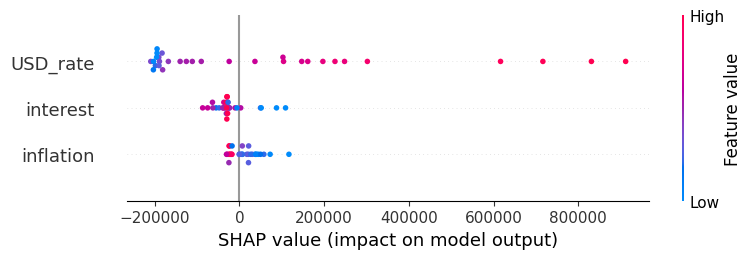

In [ ]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

In [ ]:
# Hyperparameting Tuning
# Use Grid Search or Random Search.
from sklearn.model_selection import GridSearchCV